# Stage 1 · Memory training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedzait20003/TableMind/blob/main/src/notebooks/01_memory.ipynb)

Trains the T5 memory encoder on PAQ question–passage pairs with an in-batch contrastive loss (a question's **key** must pick out its own passage's **value**), then fills the key-value memory store and uploads it for stage 2. Run once; every pretraining run (all seeds, with and without memory) reuses it.

**Next:** `02_pretrain.ipynb`

## Setup

On Colab, pick **Runtime → Change runtime type → T4 GPU** first.

In [1]:
# Environment setup: clones the repo on Colab, uses the local checkout otherwise
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/mohamedzait20003/TableMind.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/TableMind"):
        !git clone -q {REPO_URL} /content/TableMind
    %cd /content/TableMind
    !pip install -q -r requirements.txt
else:
    # Local run (e.g. from src/notebooks): move up to the repository root
    os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists()))

sys.path.insert(0, os.path.abspath("src"))
print("Working directory:", os.getcwd())

/content/TableMind
Working directory: /content/TableMind


In [3]:
from utils import load_config, set_seed, resolve_device, get_storage_dir

# DoT setup: tapas-small prunes 1024 -> 256 tokens for a t5-base task model,
# trained on the full WikiSQL training set
CONFIG_PATH = "src/config/default.yaml"

config = load_config(CONFIG_PATH)
device = resolve_device(config["system"]["device"])
set_seed(config["system"]["seed"])

# Google Drive on Colab (you will be asked to authorize), ./storage locally
STORAGE = get_storage_dir(config["storage"]["drive_subdir"], config["storage"]["local_dir"])
CHECKPOINT_DIR = config["system"]["checkpoint_dir"]
OUTPUT_DIR = config["system"]["output_dir"]
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config: {CONFIG_PATH} ({config['experiment']['name']})")
print(f"Device: {device} | storage: {STORAGE}")

Mounted at /content/drive
Config: src/config/default.yaml (dot_t5_memory)
Device: cuda | storage: /content/drive/MyDrive/TableMind/checkpoints


## Load PAQ

A shuffled sample is streamed from the Hub, so the full ~5 GB dataset is never downloaded.

In [4]:
import torch
from torch.utils.data import DataLoader, random_split
from utils import PAQDataset

paq = PAQDataset.from_config(config)

n_eval = max(1, int(config["data"]["paq"]["eval_ratio"] * len(paq)))
paq_train, paq_eval = random_split(
    paq, [len(paq) - n_eval, n_eval],
    generator=torch.Generator().manual_seed(config["system"]["seed"]),
)

mem_cfg = config["memory_training"]
workers = config["system"]["num_workers"]
# drop_last keeps the number of in-batch negatives constant
train_loader = DataLoader(paq_train, batch_size=mem_cfg["batch_size"], shuffle=True,
                          drop_last=True, num_workers=workers)
eval_loader = DataLoader(paq_eval, batch_size=mem_cfg["batch_size"], num_workers=workers)

print(f"PAQ pairs: {len(paq)} (train {len(paq_train)}, eval {len(paq_eval)})")
question, passage = paq.pairs[0]
print("Q:", question)
print("P:", passage[:200], "...")

README.md:   0%|          | 0.00/5.41k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

PAQ pairs: 30000 (train 28500, eval 1500)
Q: what is the name of the uk legislation that repealed recreational charities act 1958,
P: 2006. Charities Act 2011 The Charities Act 2011 (c 25) is a UK Act of Parliament. It consolidated the bulk of the Charities Act 2006, outstanding provisions of the Charities Act 1993, and various othe ...


## Train the memory encoder

`eval_retrieval_accuracy` is the in-batch top-1 accuracy: how often a question's key is closest to its own passage among the batch.

In [5]:
from core import MemoryEncoder, MemoryTrainer

memory_encoder = MemoryEncoder.from_config(config)

trainer = MemoryTrainer(
    memory_encoder, train_loader, eval_loader,
    device=device,
    temperature=mem_cfg["temperature"],
    num_epochs=mem_cfg["num_epochs"],
    learning_rate=mem_cfg["learning_rate"],
    weight_decay=mem_cfg["weight_decay"],
    warmup_ratio=mem_cfg["warmup_ratio"],
    log_steps=mem_cfg["log_steps"],
)

print("Before training:", trainer.evaluate())
trainer.train()

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 47/47 [00:16<00:00,  2.84it/s]


Before training: {'eval_loss': 3.6545058920028364, 'eval_retrieval_accuracy': 0.030666666666666665}
Training on cuda for 1 epoch(s), 110,022,272 trainable parameters


Evaluating: 100%|██████████| 47/47 [00:19<00:00,  2.45it/s]

Epoch 1/1 - Train Loss: 0.8071 - eval_loss: 0.3146 - eval_retrieval_accuracy: 0.9107


([0.807110214702199],
 [{'eval_loss': 0.3146012820144917,
   'eval_retrieval_accuracy': 0.9106666666666666}])

Training curves saved: ./outputs/memory_curves.png


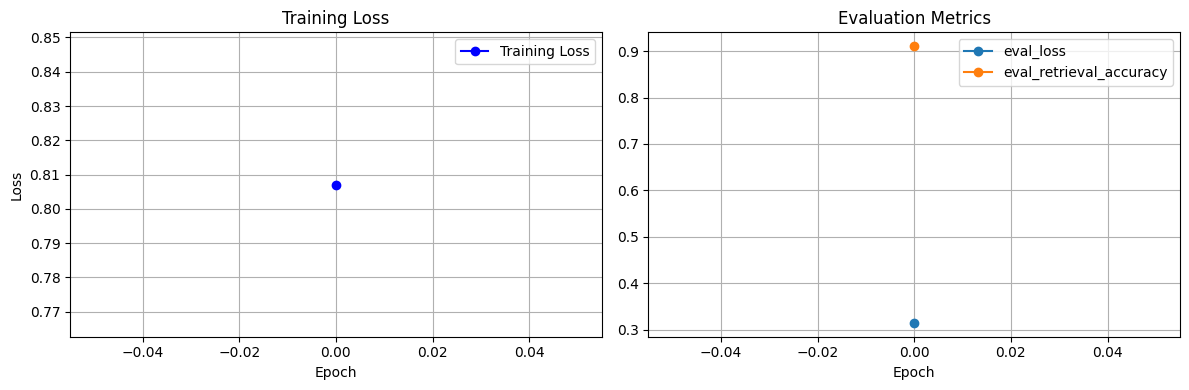

In [6]:
trainer.plot_training_curves(os.path.join(OUTPUT_DIR, "memory_curves.png"))

## Fill the memory store

Every PAQ pair becomes one entry: normalized question key → passage value.

In [7]:
from core import KeyValueMemoryStore

memory_store = KeyValueMemoryStore()
encode_loader = DataLoader(paq, batch_size=mem_cfg["encode_batch_size"], num_workers=workers)
trainer.populate_store(memory_store, encode_loader)

Encoding PAQ to Memory: 100%|██████████| 469/469 [06:12<00:00,  1.26it/s]

Encoded 30000 entries to memory store


## Sanity check: retrieval over the whole memory

For held-out pairs, does each passage's value land closest to its own question key among *all* stored entries? (Store index *i* is PAQ pair *i*.)

In [8]:
import torch.nn.functional as F

keys = torch.stack(memory_store.keys)
values = torch.stack(memory_store.values)
eval_idx = torch.tensor(paq_eval.indices)

sims = F.normalize(values[eval_idx], dim=-1) @ keys.t()
top5 = sims.topk(5, dim=1).indices
recall1 = (top5[:, 0] == eval_idx).float().mean().item()
recall5 = (top5 == eval_idx.unsqueeze(1)).any(dim=1).float().mean().item()
print(f"Recall@1: {recall1:.3f} | Recall@5: {recall5:.3f} over {memory_store.size()} entries")

for i in eval_idx[:3].tolist():
    best = sims[(eval_idx == i).nonzero()[0, 0]].argmax().item()
    print(f"\nQ:         {paq.pairs[i][0]}\nRetrieved: {paq.pairs[best][0]}")

Recall@1: 0.164 | Recall@5: 0.335 over 30000 entries

Q:         why does paraguay want to be ecotouristic
Retrieved: why is the island of isla natividad so important to marine life

Q:         what are the sons name in love express
Retrieved: what is the name of the cop in ghajinikanth movie

Q:         what was the first mass produced car made by ford
Retrieved: what was the first mass produced car made by ford


## Save and upload

The encoder weights and the filled store go into one checkpoint, uploaded to Drive for `02_pretrain.ipynb`.

In [10]:
from utils import save_checkpoint, upload_checkpoint

memory_path = os.path.join(CHECKPOINT_DIR, config["storage"]["memory_checkpoint"])
save_checkpoint(memory_path, memory_encoder, memory_store=memory_store, trainer=trainer, config=config)
upload_checkpoint(memory_path, STORAGE)

Checkpoint saved: ./checkpoints/memory_stage.pt
Uploaded: /content/drive/MyDrive/TableMind/checkpoints/memory_stage.pt


'/content/drive/MyDrive/TableMind/checkpoints/memory_stage.pt'